# Railway Track Event Detection Project at LTU Sweden

Filip Drincic, LTU.

Course: Industrial AI and eMaintenance

Goal: Detect transient railway impact events using extracted signal features. Binary classification: normal (0) vs impact/event (1)

# Problem description: 
Railway infrastructure monitoring is essential for ensuring operational safety and reliability. Impact events on railway tracks, such as wheel defects, rail irregularities, or external disturbances, can generate abnormal vibration signals. Detecting these events automatically from sensor data is a challenging task due to noise, variability in operating conditions, and the complexity of signal patterns.

The objective of this LTU project is to develop a machine learning-based event detection system capable of distinguishing between normal railway operation and abnormal impact events using vibration signal features. The dataset consists of multiple trials containing extracted statistical and spectral features from railway measurements. The goal is to preprocess the dataset, train classification models, evaluate their performance, and identify the most relevant features for accurate event detection.

Accurate detection of such events is important for predictive maintenance and smart monitoring, where early identification of anomalies can help prevent failures, reduce maintenance costs, and improve railway safety.

# Method of solution:
The event detection system was implemented using a structured machine learning workflow consisting of the following steps:

Step 1 — Data Loading and Integration

Three separate datasets (CSV format) were loaded and combined into a single unified dataset to increase the number of samples and improve model robustness. This integration allows the machine learning model to learn from a more diverse set of conditions.

Step 2 — Data Preprocessing

Several preprocessing operations were applied to prepare the dataset for machine learning:

a) Removal of unnecessary columns (start_time, axle, cluster, tsne_1, tsne_2) that do not contribute to classification.

b) Conversion of the event label into binary form, where normal events were assigned value 0 and abnormal events were assigned value 1.

c) Separation of input features (X) and target variable (y).

Step 3 — Data Normalization

Feature normalization was performed using the StandardScaler method to ensure that all features have comparable scales. This step is particularly important for algorithms such as Support Vector Machines, which are sensitive to feature magnitude differences.

Step 4 — Dataset Splitting

The dataset was divided into training and testing subsets using an 80/20 split ratio. The training set was used to train the model, while the testing set was used to evaluate its performance on unseen data.

Step 5 — Model Training Using SVM

A Support Vector Machine (SVM) classifier with a radial basis function (RBF) kernel was trained on the training dataset. The SVM algorithm was selected due to its effectiveness in handling non-linear classification problems and high-dimensional data.

Step 6 — Cross-Validation

To evaluate model stability and generalization ability, 5-fold Cross-Validation was performed on the training dataset. This method divides the training data into multiple subsets and evaluates the model repeatedly, providing a more reliable estimate of performance compared to a single split.

Step 7 — Performance Evaluation

Model performance was evaluated using several metrics, including:

- Accuracy

- Precision

- F1-score

- Confusion matrix

These metrics provide insight into classification quality and the ability to detect abnormal events correctly.

Step 8 — Feature Selection

Multiple feature selection techniques were applied to identify the most relevant features and reduce dimensionality:

a) Pearson correlation analysis (filter method)

b) Chi-square test (filter method)

c) Recursive Feature Elimination (wrapper method)

d) Random Forest feature importance (embedded method)

Feature selection helps improve model interpretability and may enhance classification performance by removing irrelevant or "noisy" features.

Step 9 — Model Improvement Using Selected Features

The SVM model was retrained using the selected features obtained from Recursive Feature Elimination. The performance was compared with the original model to evaluate the impact of feature selection.

# Steps to implement event detection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.feature_selection import SelectKBest, chi2, RFE
from sklearn.ensemble import RandomForestClassifier

In [3]:
print("Current working directory:", os.getcwd())  # for troubleshooting purpose

df1 = pd.read_csv("trail1.csv")
df2 = pd.read_csv("trail2.csv")
df3 = pd.read_csv("trail3.csv")

Current working directory: C:\Users\fildr\Python_LTU


In [4]:
df = pd.concat([df1, df2, df3], ignore_index=True)
print("Dataset shape:", df.shape)

Dataset shape: (150, 22)


In [5]:
columns_to_remove = ['start_time', 'axle', 'cluster', 'tsne_1', 'tsne_2']
df = df.drop(columns=columns_to_remove, errors='ignore')

In [6]:
df['event'] = df['event'].apply(lambda label: 0 if label == 'normal' else 1)

print("Event distribution:")
print(df['event'].value_counts())

Event distribution:
event
1    90
0    60
Name: count, dtype: int64


In [7]:
X_features = df.drop('event', axis=1)
y_target = df['event']

In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_features)

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_target,
    test_size=0.2,
    random_state=42,
    stratify=y_target
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print(f"Train size: {len(y_train)} samples")
print(f"Test size:  {len(y_test)} samples")

X_train shape: (120, 16)
X_test shape: (30, 16)
Train size: 120 samples
Test size:  30 samples


In [10]:
svm_cv = SVC(kernel="rbf", random_state=42)
cv_scores_train = cross_val_score(svm_cv, X_train, y_train, cv=5)

print("\n--- 5-Fold Cross Validation (SVM on training set) ---")
print("CV Scores:", cv_scores_train)
print("Mean CV Accuracy:", cv_scores_train.mean())
print("Standard Deviation:", cv_scores_train.std())


--- 5-Fold Cross Validation (SVM on training set) ---
CV Scores: [0.95833333 1.         0.95833333 0.91666667 1.        ]
Mean CV Accuracy: 0.9666666666666668
Standard Deviation: 0.031180478223116186


In [11]:
svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train, y_train)

y_pred = svm_model.predict(X_test)

print("\n--- 80/20 Split Results (SVM) ---")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


--- 80/20 Split Results (SVM) ---
Accuracy: 0.9333333333333333
              precision    recall  f1-score   support

           0       1.00      0.83      0.91        12
           1       0.90      1.00      0.95        18

    accuracy                           0.93        30
   macro avg       0.95      0.92      0.93        30
weighted avg       0.94      0.93      0.93        30



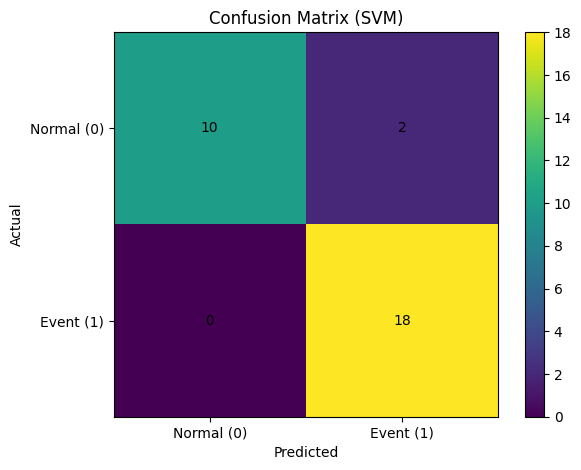

In [12]:
cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix (SVM)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xticks([0, 1], ["Normal (0)", "Event (1)"])
plt.yticks([0, 1], ["Normal (0)", "Event (1)"])
plt.tight_layout()
plt.show()

The confusion matrix above shows that the SVM classifier correctly identified 18 out of 18 event samples and 10 out of 12 normal samples. No event samples were misclassified as normal (false negatives), indicating that the model successfully detects all impact events. Two normal samples were incorrectly classified as events (false positives), which is acceptable in safety-critical applications where missing an event is more critical than generating a false alarm. Overall, the model achieved an accuracy of 93.3%, demonstrating strong classification performance.

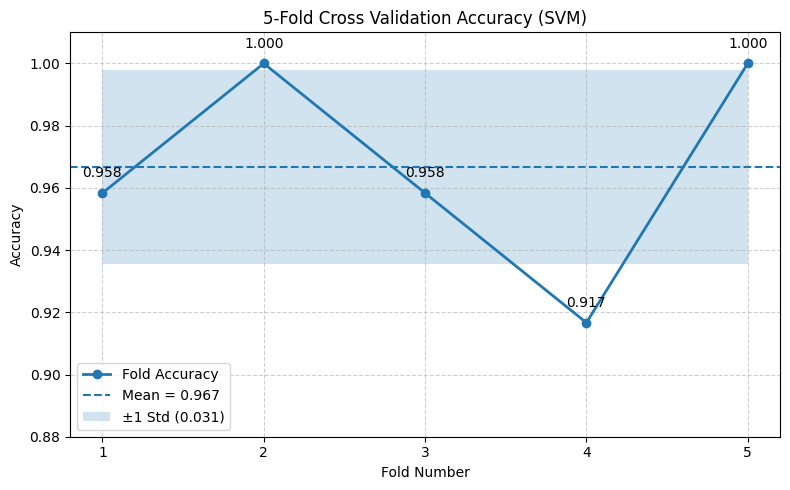

In [13]:
folds = np.arange(1, len(cv_scores_train) + 1)
mean_score = np.mean(cv_scores_train)
std_score = np.std(cv_scores_train)

plt.figure(figsize=(8, 5))
plt.plot(folds, cv_scores_train, marker='o', linewidth=2, label="Fold Accuracy")
plt.axhline(mean_score, linestyle='--', label=f"Mean = {mean_score:.3f}")

plt.fill_between(
    folds,
    mean_score - std_score,
    mean_score + std_score,
    alpha=0.2,
    label=f"±1 Std ({std_score:.3f})"
)

for fold_idx, acc in zip(folds, cv_scores_train):
    plt.text(fold_idx, acc + 0.005, f"{acc:.3f}", ha='center')

plt.title("5-Fold Cross Validation Accuracy (SVM)")
plt.xlabel("Fold Number")
plt.ylabel("Accuracy")
plt.xticks(folds)
plt.ylim(0.88, 1.01)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

The 5-fold cross-validation results show consistently high classification accuracy across all folds, with a mean accuracy of 96.7% and a standard deviation of 3.1%. Compared to the 80/20 split accuracy (93.3%), cross-validation provides a more reliable and less variance-sensitive estimate of the model’s true generalization capability.

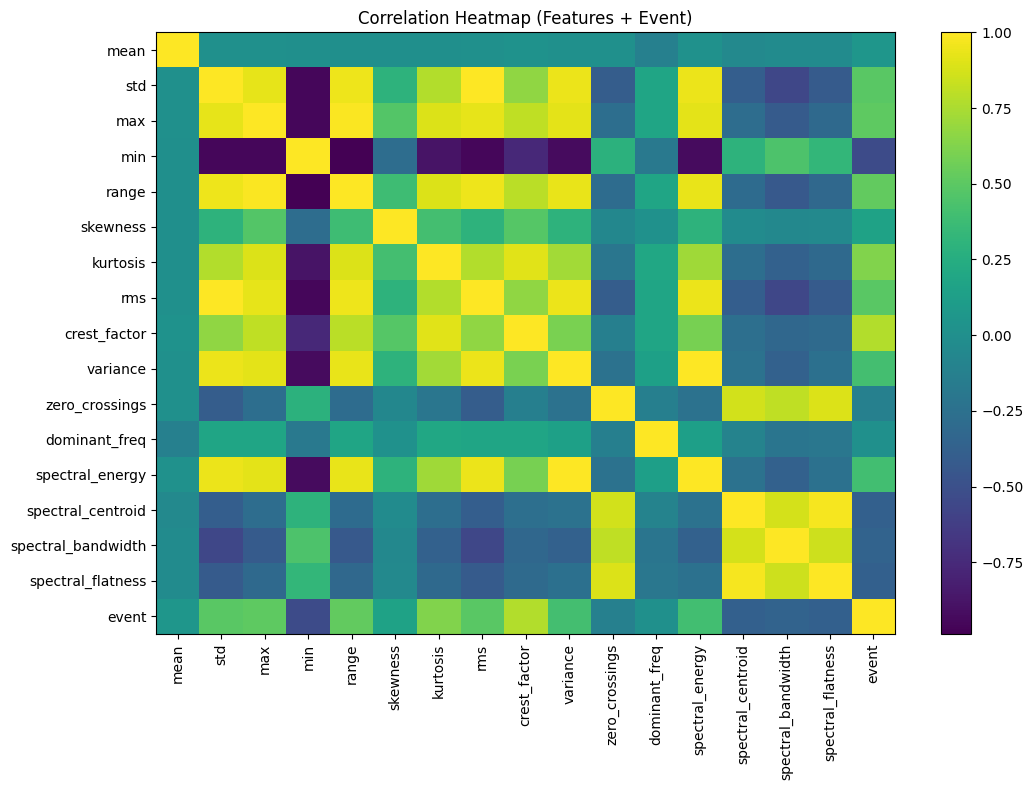

In [14]:
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(11, 8))
plt.imshow(corr_matrix, aspect='auto')
plt.title("Correlation Heatmap (Features + Event)")
plt.colorbar()

cols = corr_matrix.columns.tolist()
plt.xticks(range(len(cols)), cols, rotation=90)
plt.yticks(range(len(cols)), cols)
plt.tight_layout()
plt.show()

The correlation heatmap illustrates the relationships between extracted vibration features and the target variable (event). 
Strong positive correlations were observed between amplitude-related features such as crest factor, kurtosis, RMS, range, and variance with the event label, indicating that impact events are associated with high-energy and impulsive signal characteristics.
Kurtosis and crest factor are particularly important because they measure impulsiveness, which is a key characteristic of transient railway impact events.  

In [15]:
pearson_corr = corr_matrix["event"].abs().sort_values(ascending=False)

print("\n--- RESULTS: Top Pearson Correlations with Event ---")
print(pearson_corr.head(10))


--- RESULTS: Top Pearson Correlations with Event ---
event              1.000000
crest_factor       0.769177
kurtosis           0.624201
min                0.531723
range              0.525619
max                0.508304
std                0.490287
rms                0.490274
variance           0.405861
spectral_energy    0.402178
Name: event, dtype: float64


In [16]:
print("\n==============================")
print("FEATURE SELECTION METHODS")
print("==============================")


FEATURE SELECTION METHODS


In [17]:
print("\nTop correlated features (Pearson):")
print(pearson_corr.drop("event").head(10))


Top correlated features (Pearson):
crest_factor         0.769177
kurtosis             0.624201
min                  0.531723
range                0.525619
max                  0.508304
std                  0.490287
rms                  0.490274
variance             0.405861
spectral_energy      0.402178
spectral_flatness    0.379142
Name: event, dtype: float64


In [18]:
minmax_scaler = MinMaxScaler()
X_minmax = minmax_scaler.fit_transform(X_features)

chi_selector = SelectKBest(chi2, k=10)
chi_selector.fit(X_minmax, y_target)  
chi_features = X_features.columns[chi_selector.get_support()]

print("\nChi-Square Selected Features:")
print(list(chi_features))


Chi-Square Selected Features:
['std', 'max', 'range', 'kurtosis', 'rms', 'crest_factor', 'variance', 'spectral_energy', 'spectral_centroid', 'spectral_flatness']


In [19]:
svm_linear = SVC(kernel='linear')
rfe = RFE(svm_linear, n_features_to_select=10)
rfe.fit(X_scaled, y_target)  
rfe_features = X_features.columns[rfe.support_]

print("\nRFE Selected Features:")
print(list(rfe_features))


RFE Selected Features:
['min', 'range', 'skewness', 'kurtosis', 'crest_factor', 'variance', 'zero_crossings', 'spectral_centroid', 'spectral_bandwidth', 'spectral_flatness']


In [20]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_scaled, y_target)

importances = pd.Series(rf.feature_importances_, index=X_features.columns).sort_values(ascending=False)

print("\nTop Random Forest Important Features:")
print(importances.head(10))


Top Random Forest Important Features:
kurtosis             0.340238
crest_factor         0.247363
max                  0.107309
min                  0.070529
range                0.056317
zero_crossings       0.039515
variance             0.023560
rms                  0.022561
spectral_flatness    0.019648
std                  0.017546
dtype: float64


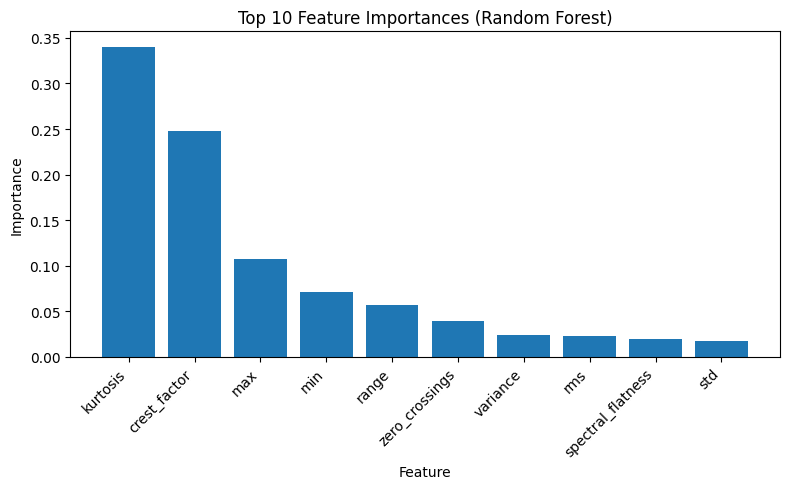

In [21]:
top_n = 10
top_features = importances.head(top_n)

plt.figure(figsize=(8, 5))
plt.bar(top_features.index, top_features.values)
plt.title(f"Top {top_n} Feature Importances (Random Forest)")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

This figure displays the top 10 most important features identified by the Random Forest model. Feature importance measures:

•	How much each feature contributes to the model’s decision-making.

•	Higher bars = more influence on classification.

The Random Forest feature importance analysis indicates that kurtosis and crest factor are the most influential features for classifying railway impact events. These features measure impulsiveness and peak amplitude characteristics, which are typical signatures of transient impact signals.



--- 80/20 Split Results (Random Forest) ---
Accuracy: 0.9666666666666667
              precision    recall  f1-score   support

           0       1.00      0.92      0.96        12
           1       0.95      1.00      0.97        18

    accuracy                           0.97        30
   macro avg       0.97      0.96      0.96        30
weighted avg       0.97      0.97      0.97        30



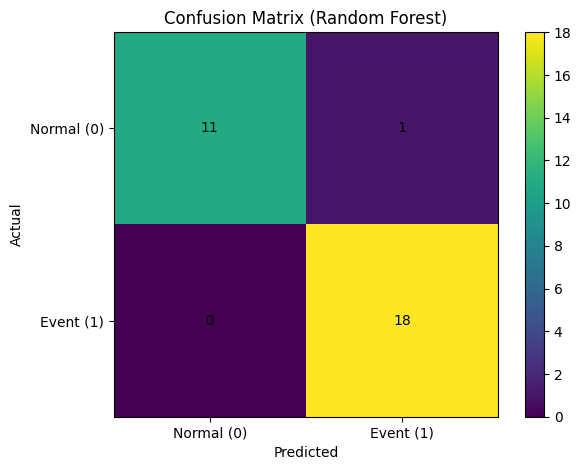

In [22]:
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_scaled, y_target,
    test_size=0.2,
    random_state=42,
    stratify=y_target
)

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_rf, y_train_rf)
rf_pred = rf_model.predict(X_test_rf)

print("\n--- 80/20 Split Results (Random Forest) ---")
print("Accuracy:", accuracy_score(y_test_rf, rf_pred))
print(classification_report(y_test_rf, rf_pred))

cm_rf = confusion_matrix(y_test_rf, rf_pred)

plt.figure()
plt.imshow(cm_rf)
plt.title("Confusion Matrix (Random Forest)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()

for i in range(cm_rf.shape[0]):
    for j in range(cm_rf.shape[1]):
        plt.text(j, i, cm_rf[i, j], ha="center", va="center")

plt.xticks([0, 1], ["Normal (0)", "Event (1)"])
plt.yticks([0, 1], ["Normal (0)", "Event (1)"])
plt.tight_layout()
plt.show()

The Random Forest confusion matrix shows excellent classification performance, with 18 correctly detected events and no missed events (false negatives). Only one normal sample was incorrectly classified as an event, resulting in an overall accuracy of 96.7%. The absence of false negatives is particularly important for railway monitoring applications, where missed impact events could indicate potential safety risks. Compared to the SVM model, Random Forest achieved slightly higher accuracy and fewer false alarms, demonstrating its effectiveness for this classification task.

In [23]:
X_selected = df[rfe_features]
X_selected_scaled = StandardScaler().fit_transform(X_selected)

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_selected_scaled, y_target,
    test_size=0.2,
    random_state=42,
    stratify=y_target
)

svm_model2 = SVC(kernel='rbf', random_state=42)
svm_model2.fit(X_train2, y_train2)
y_pred2 = svm_model2.predict(X_test2)

print("\n--- SVM After Feature Selection (RFE) ---")
print("Accuracy:", accuracy_score(y_test2, y_pred2))
print(classification_report(y_test2, y_pred2))

print("\nProject completed successfully.")


--- SVM After Feature Selection (RFE) ---
Accuracy: 0.9666666666666667
              precision    recall  f1-score   support

           0       1.00      0.92      0.96        12
           1       0.95      1.00      0.97        18

    accuracy                           0.97        30
   macro avg       0.97      0.96      0.96        30
weighted avg       0.97      0.97      0.97        30


Project completed successfully.


# Observations and reflections

The results obtained in this project demonstrate that machine learning techniques can successfully detect railway impact events using vibration signal features. The Support Vector Machine (SVM) model achieved high classification accuracy, and the confusion matrix showed that most events were correctly identified.
Cross-validation results further confirmed that the model performance was stable across different subsets of the data, indicating good generalization capability.

A comparison between the 80/20 train-test split and 5-fold cross-validation revealed that cross-validation produced slightly higher accuracy and lower variability. This is expected because cross-validation evaluates the model on multiple data partitions rather than relying on a single split. 
Therefore, cross-validation provides a more reliable estimate of model performance.

The feature selection analysis provided valuable insights into which signal characteristics are most important for event detection. Features related to impulsive behavior, such as kurtosis and crest factor, consistently showed high importance across multiple selection methods. This observation is consistent with the physical interpretation of railway impact events, which typically generate sharp peaks in vibration signals. The agreement between different feature selection techniques increased confidence in the robustness of the selected features.

The Random Forest model achieved slightly better performance than the SVM model, particularly in reducing false alarms while maintaining perfect detection of abnormal events. This improvement may be explained by the ability of ensemble methods to capture non-linear relationships and interactions between features.

One limitation of this study is the relatively small dataset size (150 samples), which may affect the generalization ability of the models in real-world applications. Future work could include collecting larger datasets, NoSQL DB, testing additional machine learning algorithms, and applying deep learning methods for automatic feature extraction.

Overall, this project demonstrates the effectiveness of machine learning for railway condition monitoring and highlights the importance of proper data preprocessing, feature selection, and model evaluation techniques in achieving reliable event detection.

# Conclusion:
This project demonstrated that machine learning techniques can effectively detect railway impact events using vibration signal features. The Support Vector Machine model achieved high accuracy, and cross-validation confirmed stable and reliable performance. Feature selection methods identified impulsive signal characteristics, such as kurtosis and crest factor, as the most important indicators of abnormal events. 
Overall, the results show that proper data preprocessing, feature selection, and model evaluation are essential for developing accurate and robust event detection systems for railway condition monitoring.